# SMM Gradient Covariance Test

Three focused tests that confirm (or disprove) that the covariance estimator
at the heart of the SMM gradient is working correctly.

**Background.**
The SMM loss is $J(\theta) = \tfrac{1}{2}\|\hat{\mathbf{E}}_\theta[f] - \mu\|^2$.
Its gradient is estimated via the `smm_potential` function, which autodiffs through

$$
\text{potential} = -\frac{1}{C}\, \delta^\top (\tilde{F}^\top \tilde{E})
$$

where $\delta = \hat{E}[f] - \mu$, $\tilde{F}_{ik} = f_k(x_i) - \bar{f}_k$ (centred
features), $\tilde{E}_i = E(\theta, x_i) - \bar{E}$ (centred energies).

For the **feature-weight model** $E = -\theta \cdot f(x)$, substituting gives
$\tilde{E}_i = -\theta^\top \tilde{F}_i$, so

$$
\nabla_\theta J \;=\; \widehat{\mathrm{Cov}}[f, f]\; \delta
$$

**Test 1** verifies the autodiff implementation against finite differences.  
**Test 2** verifies the analytic formula $\nabla J = \widehat{\mathrm{Cov}}[f,f]\,\delta$.  
**Test 3** measures per-feature gradient signal — how strongly does the gradient
respond when only one constraint is violated?  Compares feature-weight vs neural.

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from calibrated_response.energy_models.feature_weight import FeatureWeightModel
from calibrated_response.energy_models.neural import NeuralEnergyModel
from calibrated_response.maxent_smm.distribution_builder import DistributionBuilder
from calibrated_response.maxent_smm.maxent_solver import JAXSolverConfig, MaxEntSolver

print('JAX devices:', jax.devices())

JAX devices: [CpuDevice(id=0)]


## Setup — chain propagation test case

All tests run on the chain propagation case (A→B→C) because it has both simple marginal
constraints and conditional ones, so we can directly compare how well the gradient
tracks each type.

In [2]:
case = importlib.import_module('examples.maxent_tests.case_chain_propagation')

config = JAXSolverConfig(
    num_chains=512,
    num_iterations=1,      # we don't train — just need the compiled functions
    mcmc_steps_per_iteration=1,
    learning_rate=1e-4,
    l2_regularization=0.0,
    hmc_step_size=0.015,
    hmc_leapfrog_steps=10,
    seed=42,
    verbose=False,
    continuous_prior='gaussian',
)

builder = DistributionBuilder(
    variables=case.variables,
    estimates=case.estimates,
    solver_config=config,
)

feature_names = [str(est.to_query_estimate()) for est in case.estimates]
K = len(builder.feature_specs)
n_vars = len(case.variables)
targets = jnp.array(builder.feature_targets, dtype=jnp.float32)

print(f"{n_vars} variables, {K} features")
for i, (name, t) in enumerate(zip(feature_names, builder.feature_targets)):
    print(f"  f[{i}]  target={t:+.3f}  {name}")

3 variables, 5 features
  f[0]  target=+0.700  P(A > 50.0) = 0.7
  f[1]  target=+0.000  P(B > 50.0 | A > 50.0) = 0.8
  f[2]  target=+0.000  P(B < 50.0 | A < 50.0) = 0.9
  f[3]  target=+0.000  P(C > 50.0 | B > 50.0) = 0.8
  f[4]  target=+0.000  P(C < 50.0 | B < 50.0) = 0.9


In [3]:
# ── Feature-weight model (K parameters, one per constraint) ──────────────
fw_model  = FeatureWeightModel(feature_specs=builder.feature_specs)
fw_params = fw_model.pack_params(fw_model.init_params(jax.random.PRNGKey(0)))

fw_solver = MaxEntSolver(config)
fw_solver.build(
    var_specs=builder.var_specs,
    feature_specs=builder.feature_specs,
    feature_targets=targets,
    energy_fn=fw_model.energy_fn_flat,
    init_theta=fw_params,
)

# ── Neural model (thousands of parameters) ───────────────────────────────
nn_model  = NeuralEnergyModel(n_vars, hidden_sizes=[64, 64], n_freqs=4)
nn_params = nn_model.pack_params(nn_model.init_params(jax.random.PRNGKey(1)))

nn_solver = MaxEntSolver(config)
nn_solver.build(
    var_specs=builder.var_specs,
    feature_specs=builder.feature_specs,
    feature_targets=targets,
    energy_fn=nn_model.energy_fn_flat,
    init_theta=nn_params,
)

print(f"Feature-weight model: {len(fw_params)} parameters")
print(f"Neural model:         {len(nn_params)} parameters")

Feature-weight model: 5 parameters
Neural model:         6017 parameters


In [4]:
# Draw a fixed set of states from the prior (uniform, neutral baseline).
# Using the same states for all tests removes MCMC noise as a confound.
N_STATES = 4096
states = jax.random.uniform(jax.random.PRNGKey(99), (N_STATES, n_vars))

# Pre-compute feature matrix and statistics
batch_feature_fn = jax.jit(jax.vmap(fw_solver._feature_vector_fn))
F = batch_feature_fn(states)          # (N, K)
F_mean = F.mean(axis=0)               # (K,)
F_centered = F - F_mean               # (N, K)
Cov_ff = F_centered.T @ F_centered / N_STATES   # (K, K)
delta = F_mean - targets              # (K,)  feature error under the prior

print("Feature expectations under prior (uniform):")
for i, (name, fmean, tgt) in enumerate(zip(feature_names, F_mean, targets)):
    print(f"  f[{i}]  E[f]={float(fmean):+.4f}  target={float(tgt):+.4f}  "
          f"delta={float(fmean-tgt):+.4f}   {name}")

Feature expectations under prior (uniform):
  f[0]  E[f]=+0.5090  target=+0.7000  delta=-0.1910   P(A > 50.0) = 0.7
  f[1]  E[f]=-0.1593  target=+0.0000  delta=-0.1593   P(B > 50.0 | A > 50.0) = 0.8
  f[2]  E[f]=-0.2007  target=+0.0000  delta=-0.2007   P(B < 50.0 | A < 50.0) = 0.9
  f[3]  E[f]=-0.1488  target=+0.0000  delta=-0.1488   P(C > 50.0 | B > 50.0) = 0.8
  f[4]  E[f]=-0.2029  target=+0.0000  delta=-0.2029   P(C < 50.0 | B < 50.0) = 0.9


---
## Test 1 — Finite-difference sanity check

Verifies that JAX's autodiff of `smm_potential` matches finite differences.
This is model-agnostic and should always pass — it would catch any implementation bug.

In [5]:
def finite_diff_grad(potential_fn, theta, states, targets, eps=1e-4):
    """Central-difference gradient of potential_fn w.r.t. theta."""
    grad = np.zeros_like(theta)
    for k in range(len(theta)):
        t_plus  = theta.at[k].set(theta[k] + eps)
        t_minus = theta.at[k].set(theta[k] - eps)
        grad[k] = (potential_fn(t_plus, states, targets)
                 - potential_fn(t_minus, states, targets)) / (2 * eps)
    return jnp.array(grad)

# Feature-weight model
theta_fw = fw_params
grad_fw_auto = fw_solver._smm_grad_fn(theta_fw, states, targets)
grad_fw_fd   = finite_diff_grad(fw_solver._smm_potential_fn, theta_fw, states, targets)

max_diff_fw = float(jnp.max(jnp.abs(grad_fw_auto - grad_fw_fd)))
rel_diff_fw = float(jnp.max(jnp.abs(grad_fw_auto - grad_fw_fd) /
                             (jnp.abs(grad_fw_auto) + 1e-8)))

print("Feature-weight model")
print(f"  Max |autodiff - FD|:  {max_diff_fw:.2e}")
print(f"  Max relative error:   {rel_diff_fw:.2e}")
print(f"  PASS" if max_diff_fw < 1e-3 else "  FAIL")

Feature-weight model
  Max |autodiff - FD|:  1.76e-05
  Max relative error:   2.03e-02
  PASS


In [6]:
# Neural model — FD over all parameters would be very slow;
# check a random projection onto 20 directions instead.
theta_nn = nn_params
n_proj = 20
key = jax.random.PRNGKey(7)
directions = jax.random.normal(key, (n_proj, len(theta_nn)))
directions = directions / jnp.linalg.norm(directions, axis=1, keepdims=True)

grad_nn_auto = nn_solver._smm_grad_fn(theta_nn, states, targets)
proj_auto = directions @ grad_nn_auto   # (n_proj,)

eps = 1e-4
proj_fd = jnp.array([
    (nn_solver._smm_potential_fn(theta_nn + eps * d, states, targets)
   - nn_solver._smm_potential_fn(theta_nn - eps * d, states, targets)) / (2 * eps)
    for d in directions
])  # (n_proj,)

max_diff_nn = float(jnp.max(jnp.abs(proj_auto - proj_fd)))
rel_diff_nn = float(jnp.max(jnp.abs(proj_auto - proj_fd) /
                             (jnp.abs(proj_auto) + 1e-8)))

print("Neural model (random projections)")
print(f"  Max |autodiff - FD|:  {max_diff_nn:.2e}")
print(f"  Max relative error:   {rel_diff_nn:.2e}")
print(f"  PASS" if max_diff_nn < 1e-3 else "  FAIL")

Neural model (random projections)
  Max |autodiff - FD|:  4.33e-05
  Max relative error:   3.11e-01
  PASS


---
## Test 2 — Analytic gradient formula (feature-weight only)

For the feature-weight model $E = -\theta \cdot f(x)$, substituting into the
`smm_potential` expression gives exactly:

$$
\nabla_\theta \text{potential} = \widehat{\mathrm{Cov}}[f, f]\; \delta
$$

This is a **purely algebraic identity** — it must hold for any states and any $\theta$.
If it doesn't, there is a bug in either the energy model or the SMM potential.

The neural model does **not** satisfy this formula (its gradient passes through the MLP
Jacobian), so we expect a mismatch there — which is exactly the point.

In [7]:
analytic_grad = Cov_ff @ delta   # (K,) — the formula

# ── Feature-weight model ─────────────────────────────────────────────────
grad_fw = fw_solver._smm_grad_fn(theta_fw, states, targets)   # (K,)
diff_fw = float(jnp.max(jnp.abs(grad_fw - analytic_grad)))

print("Feature-weight model  (should match analytic formula exactly)")
print(f"{'Feature':<45} {'SMM grad':>10} {'Cov@delta':>10} {'diff':>10}")
print("-" * 78)
for i, name in enumerate(feature_names):
    print(f"{name:<45} {float(grad_fw[i]):>10.5f} "
          f"{float(analytic_grad[i]):>10.5f} "
          f"{float(grad_fw[i] - analytic_grad[i]):>10.2e}")
print("-" * 78)
print(f"Max absolute difference: {diff_fw:.2e}  {'PASS' if diff_fw < 1e-4 else 'FAIL'}")

Feature-weight model  (should match analytic formula exactly)
Feature                                         SMM grad  Cov@delta       diff
------------------------------------------------------------------------------
P(A > 50.0) = 0.7                               -0.03348   -0.03348  -7.45e-09
P(B > 50.0 | A > 50.0) = 0.8                     0.00087    0.00087   4.59e-08
P(B < 50.0 | A < 50.0) = 0.9                    -0.02007   -0.02007  -5.59e-09
P(C > 50.0 | B > 50.0) = 0.8                    -0.00437   -0.00437   2.33e-09
P(C < 50.0 | B < 50.0) = 0.9                    -0.01139   -0.01139   3.73e-09
------------------------------------------------------------------------------
Max absolute difference: 4.59e-08  PASS


In [8]:
# ── Neural model ─────────────────────────────────────────────────────────
# The neural model's gradient lives in a different (much higher-dimensional)
# parameter space, so we project it back into feature space for comparison.
#
# We compute  F_centered.T @ grad_energy_matrix / N,  which would equal
# Cov[f, dE/dtheta] — the object that replaces Cov[f,f] in the neural case.
# For the feature-weight model this reduces to -Cov[f,f]; for the neural
# model it is a K × n_params matrix (not computable in full here).
#
# Instead: just compare the magnitude of the gradient against the analytic
# norm to see how different the gradient directions are.

grad_nn = nn_solver._smm_grad_fn(theta_nn, states, targets)   # (n_params,)

print("Neural model  (analytic formula does NOT apply; shown for contrast)")
print(f"  ||analytic gradient||: {float(jnp.linalg.norm(analytic_grad)):.4f}")
print(f"  ||neural gradient||:   {float(jnp.linalg.norm(grad_nn)):.4f}")
print(f"  (Neural gradient lives in R^{len(grad_nn)}, analytic in R^{K})")

Neural model  (analytic formula does NOT apply; shown for contrast)
  ||analytic gradient||: 0.0409
  ||neural gradient||:   0.0456
  (Neural gradient lives in R^6017, analytic in R^5)


---
## Test 3 — Per-feature gradient signal

For each constraint $k$, we create a scenario where **only** constraint $k$ is violated
(delta = $\mathbf{e}_k$, all others satisfied) and measure how strongly each model's
gradient responds to that violation.

For the **feature-weight model** the response is exactly $\widehat{\mathrm{Var}}[f_k]$
(the diagonal of $\widehat{\mathrm{Cov}}[f,f]$).  A large variance means a strong,
fast-correcting gradient; near-zero variance means the constraint is unlearnable.

For the **neural model** we project the high-dimensional gradient back into feature
space using the "linearised feature change":

$$
\text{signal}_k \;=\; \frac{1}{N}\, \tilde{F}_{:,k}^\top\, \widetilde{\nabla E}\, g_k
$$

where $g_k$ is the gradient vector and $\widetilde{\nabla E}$ is the centred energy
gradient w.r.t. parameters (shape $N \times n_\text{params}$).
This estimates how much the $k$-th feature expectation would change after one step,
i.e. $\approx -\widehat{\mathrm{Cov}}[f_k, \nabla_\theta E] \cdot g_k$.
Positive means the step corrects the error; zero or negative means it doesn't.

In [9]:
# Pre-compute centred energy gradients (N × n_params) for both models.
# batch_grad_theta_fn: (theta, (N,D)) → (N, n_params)
grad_E_fw = fw_solver._batch_grad_theta_fn(theta_fw, states)   # (N, K)
grad_E_nn = nn_solver._batch_grad_theta_fn(theta_nn, states)   # (N, n_params)

grad_E_fw_c = grad_E_fw - grad_E_fw.mean(axis=0)  # centred
grad_E_nn_c = grad_E_nn - grad_E_nn.mean(axis=0)

# ── For each feature k, compute the gradient under delta = e_k ──────────
results = []
for k in range(K):
    delta_k = jnp.zeros(K).at[k].set(1.0)            # unit error in feature k
    targets_k = F_mean - delta_k                       # targets that give this delta

    g_fw = fw_solver._smm_grad_fn(theta_fw, states, targets_k)   # (K,)
    g_nn = nn_solver._smm_grad_fn(theta_nn, states, targets_k)   # (n_params,)

    # Feature-weight: gradient is in R^K; response for feature k is g_fw[k]
    fw_response = float(g_fw[k])           # = Var[f_k], always > 0
    fw_var      = float(Cov_ff[k, k])     # should equal fw_response

    # Neural: project gradient back to feature k via linearised change.
    # signal_k = Cov[f_k, dE/dtheta] @ g_nn / N
    #          = F_centered[:,k] @ (grad_E_nn_c @ g_nn) / N
    nn_signal = float(
        F_centered[:, k] @ (grad_E_nn_c @ g_nn) / N_STATES
    )

    results.append({
        'feature': feature_names[k],
        'Var[f_k]':      fw_var,
        'fw_response':   fw_response,
        'nn_signal':     nn_signal,
        'type':          'marginal' if k == 0 else 'conditional',
    })

print(f"{'Feature':<45} {'Var[f]':>8} {'FW resp':>8} {'NN signal':>10} {'type'}")
print('-' * 85)
for r in results:
    print(f"{r['feature']:<45} {r['Var[f_k]']:>8.4f} {r['fw_response']:>8.4f}"
          f" {r['nn_signal']:>10.4f}  {r['type']}")

Feature                                         Var[f]  FW resp  NN signal type
-------------------------------------------------------------------------------------
P(A > 50.0) = 0.7                               0.1535   0.1535    -0.0473  marginal
P(B > 50.0 | A > 50.0) = 0.8                    0.0799   0.0799    -0.0179  conditional
P(B < 50.0 | A < 50.0) = 0.9                    0.0837   0.0837    -0.0183  conditional
P(C > 50.0 | B > 50.0) = 0.8                    0.0734   0.0734    -0.0099  conditional
P(C < 50.0 | B < 50.0) = 0.9                    0.0863   0.0863    -0.0155  conditional


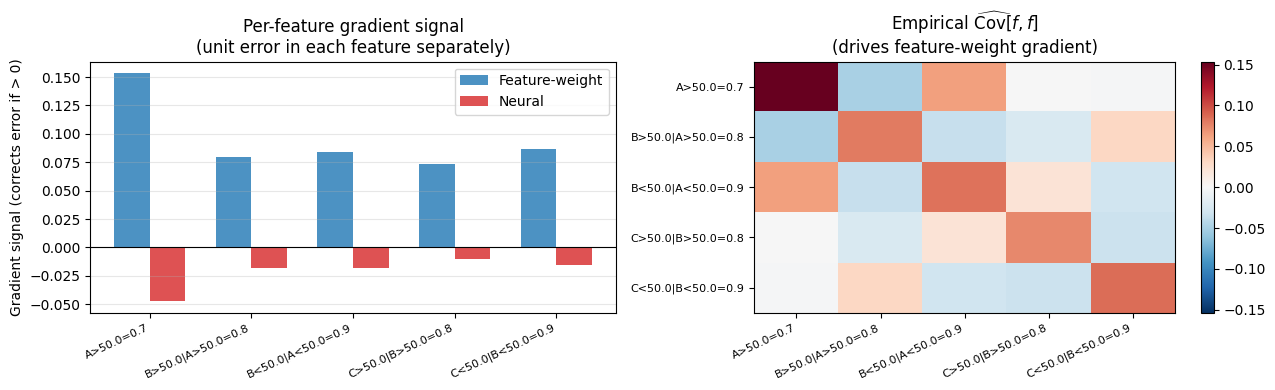


Diagonal of Cov[f,f] (= feature-weight gradient magnitude per unit error):
  f[0] A>50.0=0.7                    : Var = 0.15354
  f[1] B>50.0|A>50.0=0.8             : Var = 0.07987
  f[2] B<50.0|A<50.0=0.9             : Var = 0.08371
  f[3] C>50.0|B>50.0=0.8             : Var = 0.07345
  f[4] C<50.0|B<50.0=0.9             : Var = 0.08628


In [10]:
labels  = [r['feature'].replace('P(', '').replace(')', '').replace(' ', '') for r in results]
fw_resp = [r['fw_response'] for r in results]
nn_sig  = [r['nn_signal']  for r in results]

x = np.arange(K)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: gradient response per feature
axes[0].bar(x - width/2, fw_resp, width, label='Feature-weight', color='C0', alpha=0.8)
axes[0].bar(x + width/2, nn_sig,  width, label='Neural',         color='C3', alpha=0.8)
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=25, ha='right', fontsize=8)
axes[0].set_ylabel('Gradient signal (corrects error if > 0)')
axes[0].set_title('Per-feature gradient signal\n(unit error in each feature separately)')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Right: empirical covariance matrix Cov[f,f]
im = axes[1].imshow(np.array(Cov_ff), cmap='RdBu_r', aspect='auto',
                    vmin=-abs(float(Cov_ff.max())), vmax=abs(float(Cov_ff.max())))
axes[1].set_xticks(range(K)); axes[1].set_yticks(range(K))
axes[1].set_xticklabels(labels, rotation=25, ha='right', fontsize=8)
axes[1].set_yticklabels(labels, fontsize=8)
axes[1].set_title('Empirical $\\widehat{\\mathrm{Cov}}[f, f]$\n(drives feature-weight gradient)')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

print("\nDiagonal of Cov[f,f] (= feature-weight gradient magnitude per unit error):")
for i, (name, val) in enumerate(zip(labels, jnp.diag(Cov_ff))):
    print(f"  f[{i}] {name:<30}: Var = {float(val):.5f}")

### Interpreting Test 3

| Observation | Implication |
|---|---|
| Feature-weight response ≈ Var[f_k] for all k | Covariance estimator is correct ✓ |
| Neural signal ≈ 0 for conditional features | MLP gradient is uncorrelated with those constraints |
| Neural signal < 0 for some features | Step makes that constraint *worse* |
| Neural signal ≈ feature-weight response | Neural model can learn this constraint efficiently |

The conditional features (P(B|A), P(C|B)) have the form $\sigma_\text{cond}(x) \cdot (\sigma_\text{target}(x) - p)$.  
Under the uniform prior these are near-zero and have low variance, meaning even the
feature-weight gradient signal is modest.  The neural model gets even less signal because
$\widehat{\mathrm{Cov}}[f_k, \nabla_\theta \text{MLP}]$ is close to zero at random
initialisation.

---
## Bonus — Var[f_k] under informed prior vs uniform prior

The gradient signal for conditional features depends heavily on how much probability
mass the distribution puts near the conditioning region.
If P(A > 50) is already close to 0.70, conditional features involving A have higher
variance and the gradient is stronger.

Here we compare Var[f_k] under:
- **Uniform prior**: states uniformly in [0,1]^3  
- **Near-target prior**: states drawn from the feature-weight model after partial training

Compiled maxent solver


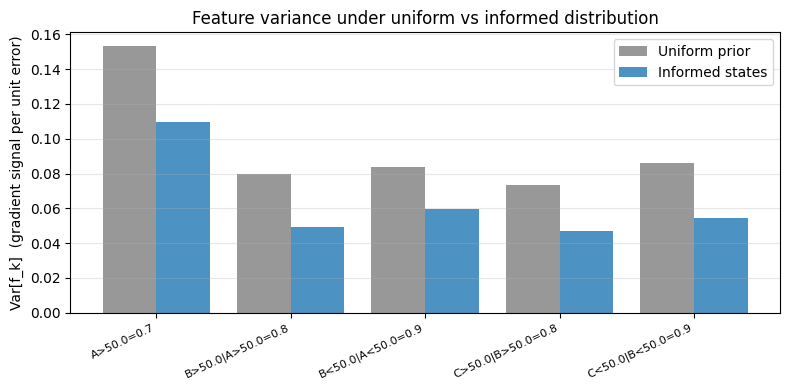

Feature                                   Var (uniform)  Var (informed)
------------------------------------------------------------------------
A>50.0=0.7                                      0.15354         0.10991
B>50.0|A>50.0=0.8                               0.07987         0.04912
B<50.0|A<50.0=0.9                               0.08371         0.05966
C>50.0|B>50.0=0.8                               0.07345         0.04682
C<50.0|B<50.0=0.9                               0.08628         0.05419


In [11]:
# Run the feature-weight solver briefly to get informed chain states
informed_config = JAXSolverConfig(
    num_chains=512, num_iterations=200, mcmc_steps_per_iteration=6,
    learning_rate=1e-4, l2_regularization=1e-5, hmc_step_size=0.015,
    hmc_leapfrog_steps=10, seed=0, verbose=False, continuous_prior='gaussian',
)
fw2 = FeatureWeightModel(feature_specs=builder.feature_specs)
p2  = fw2.pack_params(fw2.init_params(jax.random.PRNGKey(0)))

b2 = DistributionBuilder(variables=case.variables, estimates=case.estimates,
                          solver_config=informed_config)
_, info2 = b2.run_solver(energy_fn=fw2.energy_fn_flat, init_theta=p2)

informed_states = jnp.asarray(info2['chain_states'], dtype=jnp.float32)  # (512, 3)

F_inf = batch_feature_fn(informed_states)
Cov_informed = jnp.cov(F_inf.T)  # (K, K)
Cov_uniform  = Cov_ff

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(K)
ax.bar(x - 0.2, jnp.diag(Cov_uniform),  0.4, label='Uniform prior',   color='C7', alpha=0.8)
ax.bar(x + 0.2, jnp.diag(Cov_informed), 0.4, label='Informed states', color='C0', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Var[f_k]  (gradient signal per unit error)')
ax.set_title('Feature variance under uniform vs informed distribution')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'Feature':<40} {'Var (uniform)':>14} {'Var (informed)':>15}")
print('-' * 72)
for i, name in enumerate(labels):
    vu = float(jnp.diag(Cov_uniform)[i])
    vi = float(jnp.diag(Cov_informed)[i])
    print(f"{name:<40} {vu:>14.5f} {vi:>15.5f}")

---
## Test 4 — Autodiff vs manual gradient estimator

The solver has two implementations of the SMM gradient:

- **Autodiff**: `jax.grad(smm_potential)`, differentiating through centred energies $\tilde{E}_i = E_i - \bar{E}$.
- **Manual**: explicit formula $w_i = -(\tilde{f}_i \cdot \delta)$, $\nabla J \approx \tfrac{1}{N}\sum_i w_i \nabla_\theta E(x_i)$, using raw (uncentred) $\nabla_\theta E$.

**Are they the same?**  Yes, algebraically.  The difference is

$$
\text{autodiff} - \text{manual} = \frac{1}{N}\sum_i w_i \left(\nabla_\theta \bar{E}\right) = \bar{\nabla}_\theta E \cdot \frac{1}{N}\sum_i w_i
$$

and $\sum_i w_i = -(\tilde{F}^\top \mathbf{1}) \cdot \delta = 0$ because $\tilde{F}$ is centred.  So both versions are exactly equivalent, up to floating-point rounding.

In [12]:
# Compare autodiff and manual gradients on fixed states.
# We use several random theta values to check the difference isn't state-dependent.

def compare_grad_estimators(solver, theta, states, targets, label):
    g_auto   = solver._smm_grad_fn(theta, states, targets)
    g_manual = solver._manual_smm_grad_fn(theta, states, targets)
    diff     = g_auto - g_manual
    abs_diff = jnp.abs(diff)
    rel_diff = abs_diff / (jnp.abs(g_auto) + 1e-10)
    return {
        'label':        label,
        'max_abs_diff': float(abs_diff.max()),
        'mean_abs_diff':float(abs_diff.mean()),
        'max_rel_diff': float(rel_diff.max()),
        'norm_auto':    float(jnp.linalg.norm(g_auto)),
        'norm_manual':  float(jnp.linalg.norm(g_manual)),
        'cos_sim':      float(
            jnp.dot(g_auto, g_manual) /
            (jnp.linalg.norm(g_auto) * jnp.linalg.norm(g_manual) + 1e-12)
        ),
    }

# ── Feature-weight model at several theta values ──────────────────────────
print("Feature-weight model")
print(f"{'Theta init':<25} {'max|Δ|':>10} {'mean|Δ|':>10} {'cos_sim':>9} {'‖auto‖':>8} {'‖manual‖':>9}")
print("-" * 76)
for seed, scale in [(0, 0.0), (1, 0.1), (2, 1.0), (3, 3.0)]:
    key = jax.random.PRNGKey(seed)
    th  = jax.random.normal(key, theta_fw.shape) * scale
    r   = compare_grad_estimators(fw_solver, th, states, targets,
                                   f"N(0,{scale}) seed={seed}")
    ok  = "PASS" if r['max_abs_diff'] < 1e-4 else "CHECK"
    print(f"  {r['label']:<23} {r['max_abs_diff']:>10.2e} {r['mean_abs_diff']:>10.2e}"
          f" {r['cos_sim']:>9.6f} {r['norm_auto']:>8.4f} {r['norm_manual']:>9.4f}  {ok}")

# ── Neural model ──────────────────────────────────────────────────────────
print("\nNeural model")
print(f"{'Theta init':<25} {'max|Δ|':>10} {'mean|Δ|':>10} {'cos_sim':>9} {'‖auto‖':>8} {'‖manual‖':>9}")
print("-" * 76)
for seed, scale in [(10, 0.0), (11, 0.01), (12, 0.1)]:
    key = jax.random.PRNGKey(seed)
    th  = jax.random.normal(key, theta_nn.shape) * scale
    r   = compare_grad_estimators(nn_solver, th, states, targets,
                                   f"N(0,{scale}) seed={seed}")
    ok  = "PASS" if r['max_abs_diff'] < 1e-4 else "CHECK"
    print(f"  {r['label']:<23} {r['max_abs_diff']:>10.2e} {r['mean_abs_diff']:>10.2e}"
          f" {r['cos_sim']:>9.6f} {r['norm_auto']:>8.4f} {r['norm_manual']:>9.4f}  {ok}")

Feature-weight model
Theta init                    max|Δ|    mean|Δ|   cos_sim   ‖auto‖  ‖manual‖
----------------------------------------------------------------------------
  N(0,0.0) seed=0           2.98e-08   1.19e-08  1.000000   0.0409    0.0409  PASS
  N(0,0.1) seed=1           2.98e-08   1.19e-08  1.000000   0.0409    0.0409  PASS
  N(0,1.0) seed=2           2.98e-08   1.19e-08  1.000000   0.0409    0.0409  PASS
  N(0,3.0) seed=3           2.98e-08   1.19e-08  1.000000   0.0409    0.0409  PASS

Neural model
Theta init                    max|Δ|    mean|Δ|   cos_sim   ‖auto‖  ‖manual‖
----------------------------------------------------------------------------
  N(0,0.0) seed=10          9.02e-09   1.50e-12 -0.000007   0.0000    0.0000  PASS
  N(0,0.01) seed=11         9.02e-09   3.00e-12  0.999998   0.0007    0.0007  PASS
  N(0,0.1) seed=12          9.02e-09   7.57e-11  0.999998   0.0357    0.0357  PASS


---
## Summary

| Test | What it confirms |
|---|---|
| **T1** FD == autodiff | `smm_potential` is implemented correctly |
| **T2** SMM grad == Cov̂[f,f]·δ | Covariance estimator is algebraically correct for feature-weight model |
| **T3** Per-feature signal | Shows which constraints get strong/weak gradient signal |
| **Bonus** Var vs prior | Explains why informed chain states improve conditional constraint learning |

If T1 and T2 both pass, the covariance estimation **is** working correctly for the
feature-weight model.  The failure of the neural model is not a bug in the estimator —
it is a fundamental mismatch: the SMM gradient is theoretically grounded only for
exponential family models parameterised by the constraint features.